In [73]:
from xsdba.adjustment import QuantileDeltaMapping
import xarray as xr
from xclim.indices import tx_days_above, tx_max, cffwis_indices
from dask.diagnostics.progress import ProgressBar
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from ibicus.debias import ISIMIP
from indicator_delta_scaling import threshold as th
from time import perf_counter
from xclim.core.units import convert_units_to
from xsdba.utils import apply_correction, get_correction


HIST_PERIOD = ("1991", "2010")
FUT_PERIOD = ("2015", "2100")
BARCELONA = {"longitude": [2.17], "latitude": [41.39]}

variables = ["tasmax", "pr", "hurs", "sfcWind", "tas"]
models = [
    "KACE-1-0-G_r1i1p1f1",
    "ACCESS-CM2_r1i1p1f1",
    "NorESM2-MM_r1i1p1f1",
    "INM-CM5-0_r1i1p1f1",
    "INM-CM4-8_r1i1p1f1",
    "CMCC-ESM2_r1i1p1f1",
    "MIROC-ES2L_r1i1p1f2",
    "MRI-ESM2-0_r1i1p1f1",
]

save_path = Path("/prod1/benchmarks/")

# Prepare data
Save variable data as NetCDFs for a single location in Barcelona. Convert all calendars to 360-day.

In [19]:
da = cmip6['rcp45']['hurs'][models[1]].sel(time=slice("2051", "2070"))

def fill_missing_dates(da, start, end):
    mean = da.mean('time')
    days = xr.date_range(f'{start}-01-01 12:00', f'{end}-12-30 12:00', calendar='360_day')
    
    return da.reindex(time=days ).fillna(mean)
fill_missing_dates(da, '2051', '2070')

<xarray.DataArray 'hurs' (scenario: 1, realization: 1, time: 7200, latitude: 1,
                          longitude: 1)> Size: 29kB
array([[[[[75.107254]],

         [[75.107254]],

         [[75.107254]],

         ...,

         [[88.73    ]],

         [[96.03    ]],

         [[93.63    ]]]]], shape=(1, 1, 7200, 1, 1), dtype=float32)
Coordinates:
  * scenario     (scenario) object 8B 'rcp45'
  * realization  (realization) object 8B 'ACCESS-CM2_r1i1p1f1'
  * time         (time) object 58kB 2051-01-01 12:00:00 ... 2070-12-30 12:00:00
  * latitude     (latitude) int32 4B 41
  * longitude    (longitude) int32 4B 2
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        Near-surface specific humidity and near-surface mean temp...
    description:    Computed from specific humidity, temperature, and surface...
    history:        2019-11-08T10:38:13Z altered by CMOR: Treated scalar dime...
    long_name:      Near-surface Relative Humidity
    standard_name:  relative_humidity
    units:          %

In [20]:
def fill_missing_dates(da, start, end):
    mean = da.mean('time')
    days = xr.date_range(f'{start}-01-01 12:00', f'{end}-12-30 12:00', calendar='360_day')
    
    return da.reindex(time=days ).fillna(mean)


with ProgressBar():
    for i, variable in enumerate(variables, 1):
        print(f"{variable} ({i}/{len(variables)})")
        ref = xr.open_zarr(f"/prod1/regrid/era5-coarsened/{variable}.zarr")[
            variable
        ].sel(time=slice(*HIST_PERIOD))
        ref = ref.convert_calendar("360_day", align_on="year")
        ref = ref.assign_coords(time=[t.replace(hour=12) for t in ref.time.values])
        ref.sel(**BARCELONA, method="nearest").chunk(time=-1).to_netcdf(
            save_path / f"era5/{variable}_era5_barcelona.nc",
            mode="w",
            encoding={variable: {"dtype": "float32"}},
        )
        for model in models:
            hist = xr.open_zarr(
                f"/prod1/regrid/cmip6/historical/{variable}/{variable}_{model}.zarr"
            )[variable].sel(time=slice(*HIST_PERIOD))
            rcp45 = xr.open_zarr(
                f"/prod1/regrid/cmip6/rcp45/{variable}/{variable}_{model}.zarr"
            )[variable].sel(time=slice(*FUT_PERIOD))
            rcp85 = xr.open_zarr(
                f"/prod1/regrid/cmip6/rcp85/{variable}/{variable}_{model}.zarr"
            )[variable].sel(time=slice(*FUT_PERIOD))
            if hist.time.dt.calendar != "360_day":
                hist = hist.convert_calendar("360_day", align_on="year")
                rcp45 = rcp45.convert_calendar("360_day", align_on="year")
                rcp85 = rcp85.convert_calendar("360_day", align_on="year")
            fill_missing_dates(hist,*HIST_PERIOD).sel(**BARCELONA, method="nearest").chunk(time=-1).to_netcdf(
                save_path / f"historical/{variable}_hist_{model}_barcelona.nc",
                encoding={variable: {"dtype": "float32"}},
            )
            fill_missing_dates(rcp45, '2021', '2100').sel(**BARCELONA, method="nearest").chunk(time=-1).to_netcdf(
                save_path / f"rcp45/{variable}_rcp45_{model}_barcelona.nc",
                encoding={variable: {"dtype": "float32"}},
            )
            fill_missing_dates(rcp85,'2021', '2100').sel(**BARCELONA, method="nearest").chunk(time=-1).to_netcdf(
                save_path / f"rcp85/{variable}_rcp85_{model}_barcelona.nc",
                encoding={variable: {"dtype": "float32"}},
            )


tasmax (1/5)
[########################################] | 100% Completed | 815.40 ms
[########################################] | 100% Completed | 415.42 ms
[########################################] | 100% Completed | 1.14 sms
[########################################] | 100% Completed | 1.06 sms
[########################################] | 100% Completed | 412.71 ms
[########################################] | 100% Completed | 1.38 sms
[########################################] | 100% Completed | 1.27 sms
[########################################] | 100% Completed | 307.53 ms
[########################################] | 100% Completed | 1.45 sms
[########################################] | 100% Completed | 1.40 sms
[########################################] | 100% Completed | 309.76 ms
[########################################] | 100% Completed | 1.27 sms
[########################################] | 100% Completed | 1.25 sms
[########################################] | 100% Completed

## Load data
Loads Barcelona data into two dictionaries for projections and reference.

In [21]:
references = {
    variable: xr.open_dataset(save_path / f"era5/{variable}_era5_barcelona.nc")[
        variable
    ]
    for variable in variables
}

cmip6 = {
    "historical": {
        variable: {
            model: xr.open_dataset(
                save_path / f"historical/{variable}_hist_{model}_barcelona.nc"
            )[variable]
            for model in models
        }
        for variable in variables
    },
    "rcp45": {
        variable: {
            model: xr.open_dataset(
                save_path / f"rcp45/{variable}_rcp45_{model}_barcelona.nc"
            )[variable]
            for model in models
        }
        for variable in variables
    },
    "rcp85": {
        variable: {
            model: xr.open_dataset(
                save_path / f"rcp85/{variable}_rcp85_{model}_barcelona.nc"
            )[variable]
            for model in models
        }
        for variable in variables
    },
}

## Configs for flexible method testing
These configs should make testing different indicator configurations easier.


In [ ]:
base_single = {
    "kind": "+",
    "variables": ["tasmax"],
    "scenarios": ["rcp45"],
    "models": models[1:2],
    "periods": [("2051", "2070")],}

config_tx30_single = {
    **base_single,
    "indicators": [{'func': tx_days_above, 'variables': ['tasmax'], "threshold": '30 degC',}]
}

config_txx_single = {
    **base_single,
    "indicators": [{'func': tx_max, 'variables': ['tasmax']}]
}

def fwi90p(tas, pr, sfcWind, hurs):
    lat = tas.latitude.assign_attrs(units="degrees_north",
                        long_name= "Latitude")
    fwi =  cffwis_indices(tas, pr, sfcWind, hurs, lat=lat)[0]
    return fwi.resample(time='YS').quantile(q=0.9, dim='time')

config_fwi90p_single = {
    **base_single,
    'variables':['tas', 'sfcWind', 'pr', 'hurs'],
    "indicators": [{'func': fwi90p, 'variables': ['tas', 'hurs', 'pr', 'sfcWind']}],
    'ids_linear_scaling': True

}

config_tx30_all = {
    "kind": "+",
    "variables": ["tasmax"],
    "scenarios": ["rcp45", "rcp85"],
    "models": models,
    "periods": [
        ("2021", "2040"),
        ("2031", "2050"),
        ("2041", "2060"),
        ("2051", "2070"),
        ("2061", "2080"),
    ],
    "indicators": [{'func': tx_days_above, 'variables': ['tasmax'], "threshold": '30 degC'}]
}

configs = {
    'txx_single': config_txx_single,
    'tx30_single': config_tx30_single,
    'tx30_all': config_tx30_single,
    'fwi90p_single': config_fwi90p_single
}

configname='fwi90p_single'

In [95]:
def compute_indicator(adjusted, ind_conf, models, scenarios):
    kwargs = {'thresh': ind_conf['threshold']} if 'threshold' in ind_conf else {}
    func = ind_conf['func']
    for model in models:
        data = {variable: adjusted["historical"][model][variable] for variable in ind_conf['variables']}
        ind_hist = func(**data, **kwargs)
        for scenario in scenarios:
            data = {variable: adjusted[scenario][model][variable] for variable in ind_conf['variables']}
            ind_fut = func(**data,**kwargs)
    
    return ind_hist, ind_fut


## Quantile Delta Mapping

Implement and test indicator computation with Quantile Delta Mapping (QDM).

In [96]:
def qdm_adjust(ref, hist, fut):
    qdm = QuantileDeltaMapping.train(
        ref=ref, hist=hist.isel(scenario=0, drop=True), nquantiles=30, kind="+"
    )
    # qdm.ds = qdm.ds.persist()
    hist_adj = qdm.adjust(hist)
    fut_adj = qdm.adjust(fut)
    return hist_adj.transpose(*list(hist.dims)), fut_adj.transpose(*list(fut.dims))


def compute_with_qdm(config):
    adj_start = perf_counter()
    adjusted = {
        scenario: {
            model: {variable: {} for variable in config["variables"]}
            for model in config["models"]
        }
        for scenario in ["historical", *config["scenarios"]]
    }
    # Adjust all variables for all models
    for variable in config["variables"]:
        ref = references[variable]
        for model in config["models"]:
            hist = cmip6["historical"][variable][model]
            qdm = QuantileDeltaMapping.train(
                ref=ref,
                hist=hist.isel(scenario=0, drop=True),
                nquantiles=30,
                kind=config["kind"],
            )
            adjusted["historical"][model][variable] = qdm.adjust(hist)

            for scenario in config["scenarios"]:
                fut = cmip6[scenario][variable][model]

                fut_adj = []
                for period in config["periods"]:
                    try:
                        fut_adj.append(
                            qdm.adjust(fut.sel(time=slice(*period)))
                            .expand_dims(period=[f"{period[0]}-{period[1]}"])
                            .assign_coords(time=hist.time.values)
                        )
                    except Exception as e:
                        print(scenario, model, variable, period)
                        raise e
                adjusted[scenario][model][variable] = xr.concat(fut_adj, dim="period")

    adj_end = perf_counter()
    adj_time = adj_end - adj_start

    indicator_start = perf_counter()
    for ind_conf in config['indicators']:
        ind_hist, ind_fut = compute_indicator(adjusted,ind_conf, config['models'], config['scenarios'])

    indicator_end = perf_counter()

    return adj_time, indicator_end - indicator_start


### Time QDM

In [97]:
data = []
for i in range(1, 11):
    total_start = perf_counter()
    adj_time, indicator_time = compute_with_qdm(configs[configname])
    total_end = perf_counter()
    total = total_end - total_start
    data.append(
        {"total": total, "adjustment_time": adj_time, "indicator_time": indicator_time}
    )


qdm_df = pd.DataFrame(data)
qdm_df.to_csv(save_path / f"qdm_{configname}.csv", index=False)
qdm_df.head()

,total,adjustment_time,indicator_time
0,1.796476,0.411234,1.384711
1,1.741516,0.375976,1.364903
2,1.730582,0.378979,1.351289
3,1.721618,0.366409,1.353927
4,1.718872,0.372477,1.346088


## ISIMIP bias adjustment
Implement and time indicator computation with ISIMIP bias adjustment.

In [98]:
def correct_units(ref, hist, fut, units):
    kwargs = {'context':'hydro'} if ref.name=='pr' else {}
    ref = convert_units_to(ref, units, **kwargs)
    hist = convert_units_to(hist, units, **kwargs)
    fut = convert_units_to(fut, units, **kwargs)
    return ref, hist, fut

def ensure_units(ref, hist, fut):
    if 'tas' in ref.name:
        return correct_units(ref, hist, fut, 'K')
    if ref.name=='pr':
        return correct_units(ref, hist, fut, 'kg m-2 s-1')
    if ref.name=='sfcWind':
        return correct_units(ref, hist, fut, 'm s-1')
    if ref.name=='hurs':
        return correct_units(ref, hist, fut, '%')
    print(ref.name, 'units not defined')
    return ref, hist, fut
def isimimp_adjust(ref, hist, fut):
    isimip_tasmax = ISIMIP.from_variable("tas" if 'tas' in ref.name else ref.name)
    ref, hist, fut = ensure_units(ref, hist, fut)

    isimip_order = ["time", "longitude", "latitude"]
    ref_values = ref.transpose(*isimip_order).values
    hist_values = (
        hist.isel(scenario=0, realization=0, drop=True).transpose(*isimip_order).values
    )
    fut_values = (
        fut.isel(scenario=0, realization=0, drop=True).transpose(*isimip_order).values
    )

    return xr.DataArray(
        isimip_tasmax.apply(ref_values, hist_values, fut_values),
        dims=("time", "latitude", "longitude"),
        coords={"time": fut.time, "latitude": fut.latitude, "longitude": fut.longitude},
        name=fut.name,
        attrs=fut.attrs,
    )


def compute_with_isimip(config):
    adj_start = perf_counter()
    adjusted = {
        scenario: {
            model: {variable: {} for variable in config["variables"]}
            for model in config["models"]
        }
        for scenario in ["historical", *config["scenarios"]]
    }

    for variable in config["variables"]:
        ref = references[variable]
        for model in config["models"]:
            hist = cmip6["historical"][variable][model]
            adjusted["historical"][model][variable] = isimimp_adjust(ref, hist, hist)

            for scenario in config["scenarios"]:
                fut = cmip6[scenario][variable][model]

                fut_adj = []
                for period in config["periods"]:

                    fut_adj.append(
                        isimimp_adjust(ref, hist, fut.sel(time=slice(*period)))
                        .expand_dims(period=[f"{period[0]}-{period[1]}"])
                        .assign_coords(time=hist.time.values)
                    )
                adjusted[scenario][model][variable] = xr.concat(fut_adj, dim="period")

    adj_end = perf_counter()
    adj_time = adj_end - adj_start

    indicator_start = perf_counter()
    for ind_conf in config['indicators']:
        ind_hist, ind_fut = compute_indicator(adjusted,ind_conf, config['models'], config['scenarios'])

    indicator_end = perf_counter()

    return adj_time, indicator_end - indicator_start


### Time ISIMIP

In [46]:
data = []
for i in range(1, 11):
    print(i)
    total_start = perf_counter()
    adj_time, indicator_time = compute_with_isimip(configs[configname])
    total_end = perf_counter()
    total = total_end - total_start
    data.append(
        {"total": total, "adjustment_time": adj_time, "indicator_time": indicator_time}
    )


isimip_df = pd.DataFrame(data)

isimip_df.to_csv(save_path / f"isimip_{configname}.csv")

1


  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                    This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked ac

2


  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                    This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked ac

3


...

  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                    This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked ac

9


  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                    This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked ac

10


  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                    This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
  0%|          | 0/1 [00:00<?, ?it/s]/homes/sis/indicator-delta-scaling/.pixi/envs/default/lib/python3.14/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: ISIMIP runs without time-information for at least one of obs, cm_hist or cm_future.
                    This information is inferred, assuming the first observation is on a January 1st. Observations are chunked ac

## Indicator Delta Scaling
Implement and time indicator computation with Indicator Delta Scaling (IDS).
The configs need to be slightly changed because of the flexible `indicator_func`.

In [58]:
%%timeit
variables = {variable: references[variable] for variable in configs[configname]['variables']}

fwi90p(**variables)

617 ms ± 10.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [101]:
SCALING_MODE = {
    "pr": "*",
    "sfcWind": "*",
    "hurs": "*",
    "tas": "+",
    "tasmax": "+",
    "tasmin": "+",
}
def compute_with_ids(config):
    
    ref = {variable: references[variable] for variable in config['variables']}
    linear_scale = config.get('ids_linear_scaling', False)
    adjustment_time = 0
    if linear_scale:
        adjusted = {
        scenario: {
            model: {variable: {} for variable in config["variables"]}
            for model in config["models"]
        }
        for scenario in ["historical", *config["scenarios"]]
    }
        adjustment_start = perf_counter()
        for variable in config['variables']:
            ref_mean = references[variable].mean('time')

            for model in config['models']:
                hist = cmip6['historical'][variable][model]
                hist_mean = hist.mean('time')
                mode = SCALING_MODE[variable]
                correction = get_correction(hist_mean, ref_mean, kind=mode).sel(scenario='historical')
                adjusted['historical'][model][variable] = apply_correction(hist, correction, mode)
                for scenario in config['scenarios']:
                    fut = cmip6[scenario][variable][model]
                    adjusted[scenario][model][variable] = apply_correction(fut, correction, mode)
        adjustment_time += perf_counter()-adjustment_start
    
    else:
        adjusted = {
        scenario: {
            model: {variable: cmip6[scenario][variable][model] for variable in config["variables"]}
            for model in config["models"]
        }
        for scenario in ["historical", *config["scenarios"]]
    }

    threshold_time = 0
    indicator_time = 0
    delta_time = 0

    for ind_conf in config['indicators']:
        ind_ref_start = perf_counter()
        kwargs = {'thresh': ind_conf['threshold']} if 'threshold' in ind_conf else {}
        func = ind_conf['func']
        ref = {variable: references[variable] for variable in ind_conf['variables']}
        ind_ref = func(**ref, **kwargs)
        indicator_time += perf_counter() - ind_ref_start

        for model in config["models"]:
            hist = {variable: adjusted['historical'][model][variable] for variable in ind_conf['variables']}
            if 'threshold' in ind_conf:
                threshold_start = perf_counter()
                value, unit = ind_conf['threshold'].split(' ')
                kwargs['thresh'] = th.get_absolute_threshold(
                    ref, hist.sel(scenario="historical"), float(value), unit, "absolute"
                ).compute()

                threshold_time += perf_counter() - threshold_start

            indicator_hist_start = perf_counter()
            ind_hist = func(**hist, **kwargs)
            indicator_time += perf_counter() - indicator_hist_start

            for scenario in config["scenarios"]:
                indicator_fut_start = perf_counter()
                fut =  {variable: adjusted[scenario][model][variable] for variable in ind_conf['variables']}

                ind_fut = []
                for period in config["periods"]:
                    ind_fut.append(
                        func(
                            **{key: value.sel(time=slice(*period)) for key, value in fut.items()}, **kwargs
                        )
                        .expand_dims(period=[f"{period[0]}-{period[1]}"])
                        .assign_coords(time=ind_hist.time.values)
                    )
                ind_fut = xr.concat(ind_fut, dim="period")

                indicator_time += perf_counter() - indicator_fut_start

                delta_start = perf_counter()
                ind_fut_adj = ind_ref + (ind_fut - ind_hist.sel(scenario="historical"))
                delta_time += perf_counter() - delta_start

    return adjustment_time, threshold_time, indicator_time, delta_time


### Time IDS

In [102]:
data = []
for i in range(1, 11):
    print(i)
    total_start = perf_counter()
    adjustment_time, threshold_time, indicator_time, delta_time = compute_with_ids(configs[configname])
    total_end = perf_counter()
    total = total_end - total_start
    data.append(
        {
            "total": total,
            "adjustment_time": adjustment_time,
            "threshold_time": threshold_time,
            "indicator_time": indicator_time,
            "delta_time": delta_time,
        }
    )

ids_df = pd.DataFrame(data)

ids_df.to_csv(save_path / f"ids_{configname}.csv", index=False)

ids_df.head()

1
2
3
4
5
6
7
8
9
10


,total,adjustment_time,threshold_time,indicator_time,delta_time
0,2.091393,0.020183,0,2.068255,0.002753
1,2.123243,0.013425,0,2.106493,0.002830
2,1.946673,0.015219,0,1.928623,0.002630
3,1.952022,0.014282,0,1.935095,0.002501
4,1.958495,0.012770,0,1.942820,0.002552


In [78]:
config = configs[configname]
{
        scenario: {
            model: {variable: {} for variable in config["variables"]}
            for model in config["models"]
        }
        for scenario in ["historical", *config["scenarios"]]
    }

{'historical': {'ACCESS-CM2_r1i1p1f1': {'tas': {},
   'sfcWind': {},
   'pr': {},
   'hurs': {}}},
 'rcp45': {'ACCESS-CM2_r1i1p1f1': {'tas': {},
   'sfcWind': {},
   'pr': {},
   'hurs': {}}}}

## Plot different methods
Plotting the different methods in a stacked bar chart.

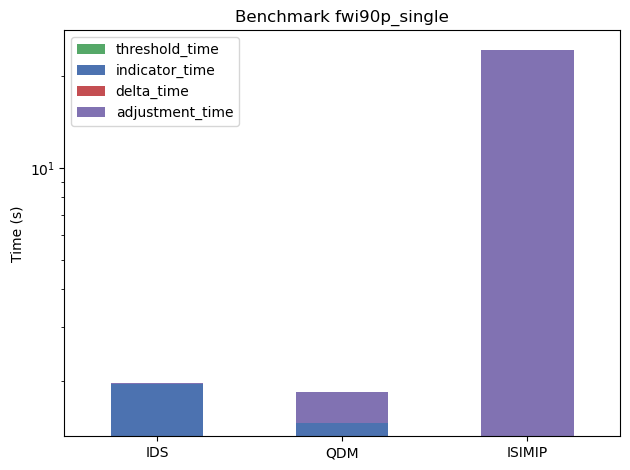

In [85]:
ids = pd.read_csv(save_path / f"ids_{configname}.csv")
qdm = pd.read_csv(save_path / f"qdm_{configname}.csv")
isimip = pd.read_csv(save_path / f"isimip_{configname}.csv")

means = pd.DataFrame(
    {
        "IDS": [
            ids["threshold_time"].mean(),
            ids["indicator_time"].mean(),
            ids["delta_time"].mean(),
            0 if 'adjustment_time' not in ids.columns else ids.adjustment_time.mean(),
        ],
        "QDM": [0, qdm["indicator_time"].mean(), 0, qdm["adjustment_time"].mean()],
        "ISIMIP": [
            0,
            isimip["indicator_time"].mean(),
            0,
            isimip["adjustment_time"].mean(),
        ],
    },
    index=["threshold_time", "indicator_time", "delta_time", "adjustment_time"],
)

colors = ["#55A868", "#4C72B0", "#C44E52", "#8172B2"]

fig, ax = plt.subplots()
means.T.plot(kind="bar", stacked=True, ax=ax, color=colors)
ax.set_yscale("log")
ax.set_ylabel("Time (s)")
ax.set_title(f"Benchmark {configname}")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


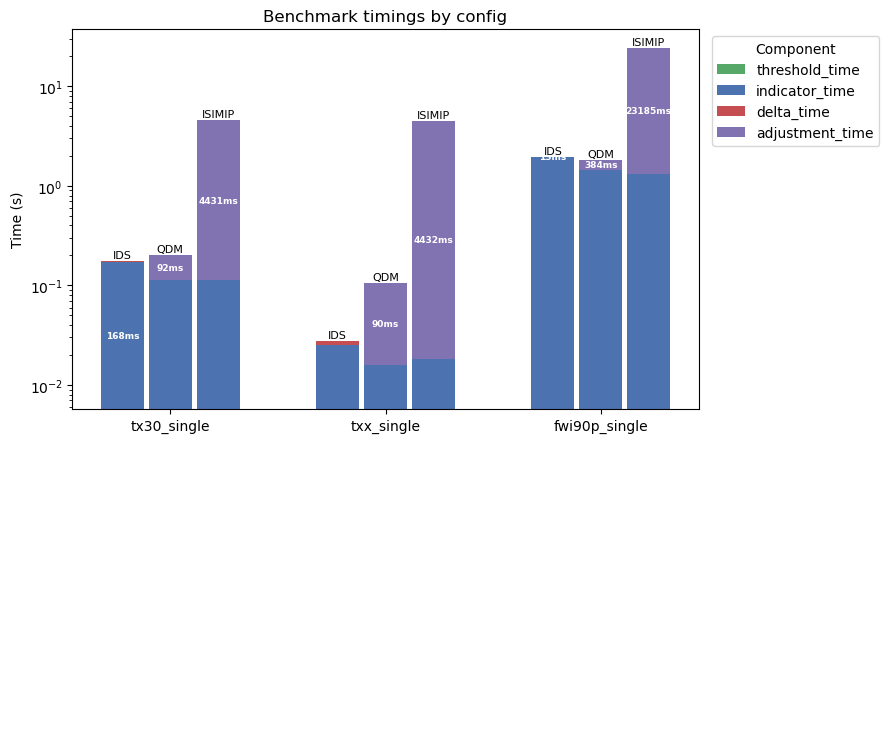

In [92]:
import numpy as np

config_names = ["tx30_single", "txx_single", 'fwi90p_single']
methods = ["IDS", "QDM", "ISIMIP"]
components = ["threshold_time", "indicator_time", "delta_time", "adjustment_time"]
colors = ["#55A868", "#4C72B0", "#C44E52", "#8172B2"]

# Load all data
all_means = {}
for cn in config_names:
    ids_d    = pd.read_csv(save_path / f"ids_{cn}.csv")
    qdm_d    = pd.read_csv(save_path / f"qdm_{cn}.csv")
    isimip_d = pd.read_csv(save_path / f"isimip_{cn}.csv")
    all_means[cn] = pd.DataFrame(
        {
            "IDS":    [ids_d["threshold_time"].mean(),   ids_d["indicator_time"].mean(),   ids_d["delta_time"].mean(),   0 if 'adjustment_time' not in ids_d.columns else ids_d.adjustment_time.mean(),],
            "QDM":    [0, qdm_d["indicator_time"].mean(),   0, qdm_d["adjustment_time"].mean()],
            "ISIMIP": [0, isimip_d["indicator_time"].mean(), 0, isimip_d["adjustment_time"].mean()],
        },
        index=components,
    )

n_groups = len(config_names)
n_methods = len(methods)
bar_width = 0.2
group_gap = 0.3
group_width = n_methods * bar_width + group_gap

fig, ax = plt.subplots(figsize=(9, 12))

legend_added = set()
for g_idx, cn in enumerate(config_names):
    group_center = g_idx * group_width
    offsets = np.arange(n_methods) * bar_width - (n_methods - 1) * bar_width / 2
    for m_idx, method in enumerate(methods):
        x = group_center + offsets[m_idx]
        bottom = 0
        for c_idx, component in enumerate(components):
            value = all_means[cn].loc[component, method]
            if value > 0:
                lbl = component if component not in legend_added else "_nolegend_"
                legend_added.add(component)
                ax.bar(x, value, bar_width * 0.9, bottom=bottom,
                       color=colors[c_idx],
                       label=lbl)
                ms = value * 1000
                if ms > 10:
                    text_y = np.sqrt(max(bottom, 1e-9) * (bottom + value))
                    ax.text(x, text_y, f"{ms:.0f}ms",
                            ha="center", va="center", fontsize=6.5, color="white", fontweight="bold")
                bottom += value
        ax.text(x, bottom * 1.02, method, ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Time (s)")
ax.set_title("Benchmark timings by config")
ax.set_xticks([g * group_width for g in range(n_groups)])
ax.set_xticklabels(config_names)
ax.set_yscale("log")
ax.legend(title="Component", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()
